# Retrieval Pipeline
---
This notebook demonstrates all three query modalities supported by the pipeline:

| Modality | Inputs | Encoded with |
|---|---|---|
| `text` | text query only | `encode_queries(text)` |
| `image` | image query only | `encode_documents(images=...)` |
| `image_text` | text + image | `encode_documents(texts=..., images=...)` |

All logic lives in the `retrieval/` package — edit `retrieval/config.py` to switch models or collections.

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("../")
print("Working dir:", os.getcwd())

Working dir: d:\Tipto\OmniChef-Nexus


## Step 1 — Load Embedding Model

In [2]:
from retrieval.model_loader import load_embedding_model

embedding_model = load_embedding_model()

Loading embedding model 'nvidia/llama-nemotron-embed-vl-1b-v2' on cuda …


Loading weights:   0%|          | 0/600 [00:00<?, ?it/s]

Model loaded successfully.


## Step 2 — Connect to Qdrant

In [3]:
from retrieval.db_client import get_qdrant_client, get_collection_info

qdrant_client = get_qdrant_client()
get_collection_info(qdrant_client)

Collection : image_text_index
Points     : 15698
Dimension  : 2048
Distance   : Cosine
Status     : green


## Step 3 — Query

Import `query_qdrant` from `retrieval.retriever` and `display_results` from `retrieval.visualizer`.
Both are independent — you can call `query_qdrant` headlessly (e.g. in a FastAPI endpoint)
and only invoke `display_results` in a notebook context.

In [4]:
from retrieval.retriever  import query_qdrant
from retrieval.visualizer import display_results

### 3a — Text-only query

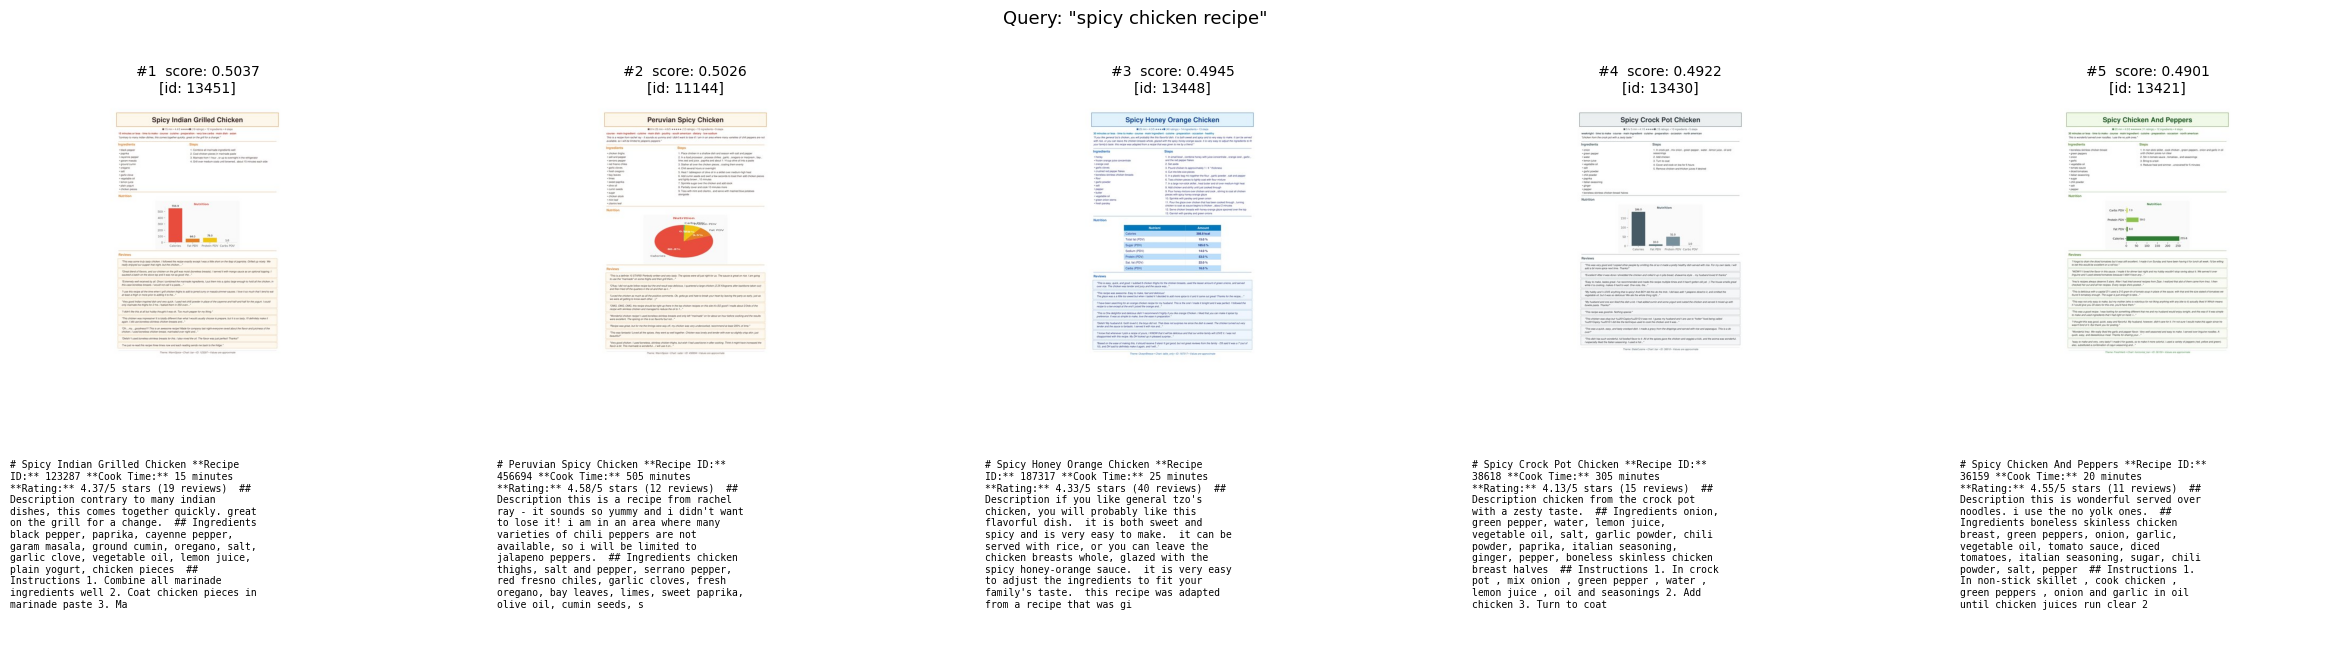

In [5]:
text_query = "spicy chicken recipe"

results = query_qdrant(
    embedding_model=embedding_model,
    qdrant_client=qdrant_client,
    text_query=text_query,
    top_k=5,
)

display_results(results, query_label=text_query)

### 3b — Image-only query

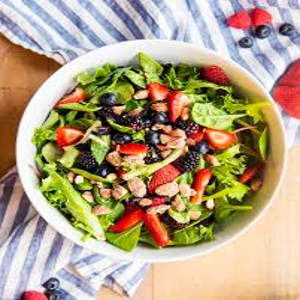

In [6]:
from transformers.image_utils import load_image

image_query = load_image("sample/example_ingredients.jpg")
image_query.resize((300, 300))

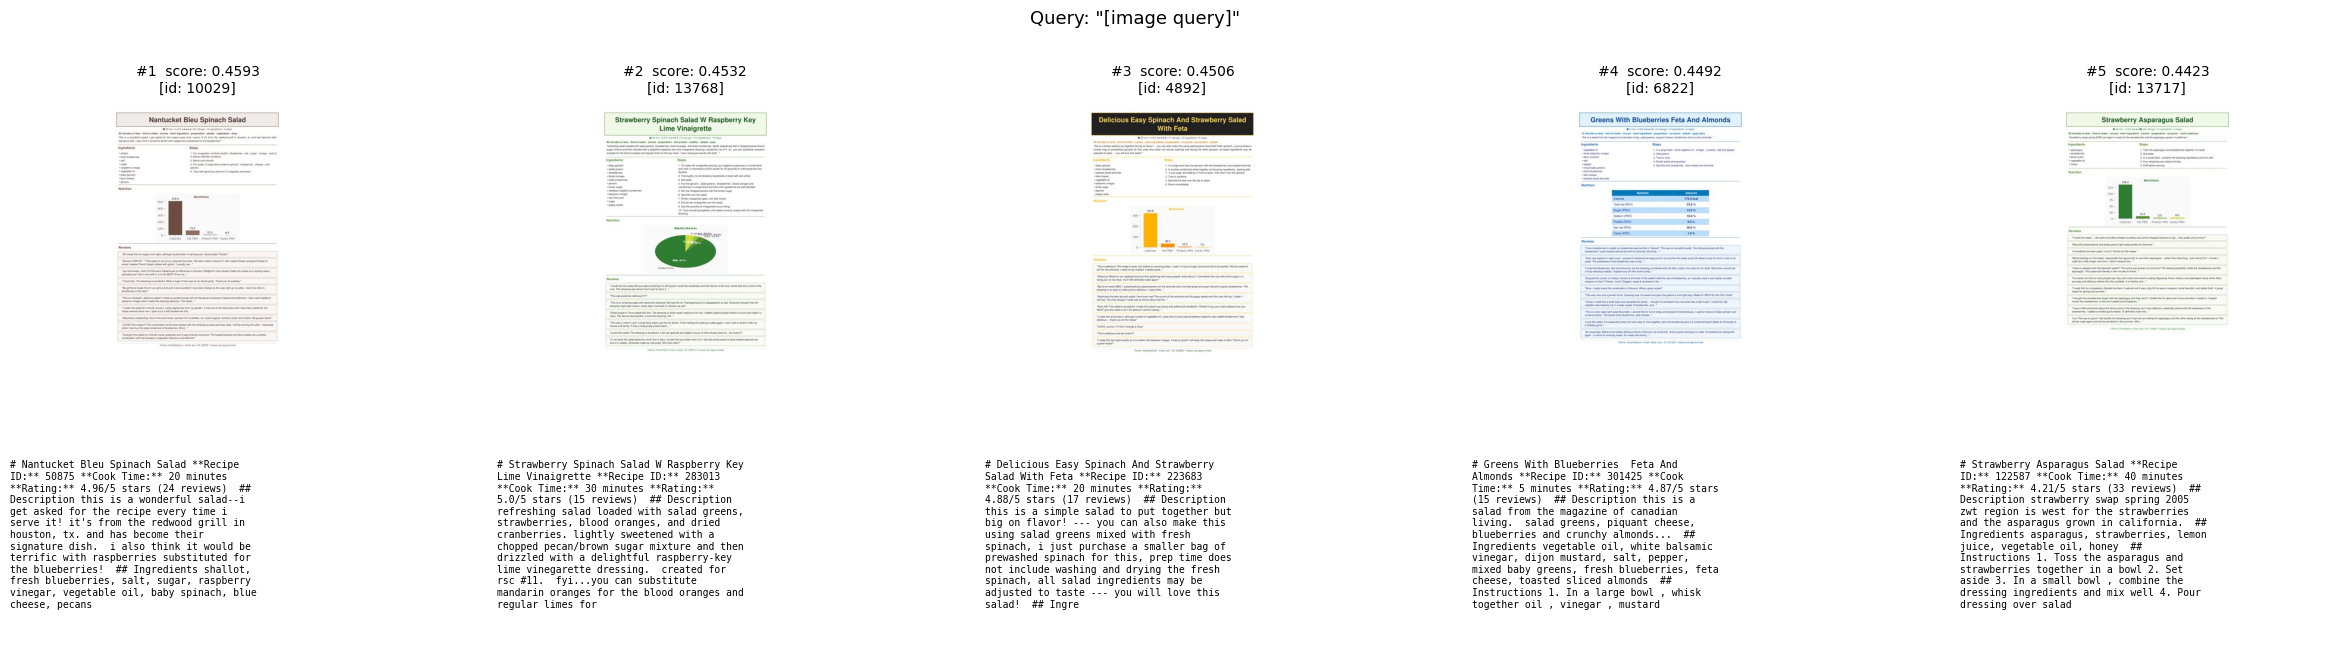

In [7]:
results = query_qdrant(
    embedding_model=embedding_model,
    qdrant_client=qdrant_client,
    image_query=image_query,
    top_k=5,
)

display_results(results, query_label="[image query]")

### 3c — Text + Image (multimodal) query

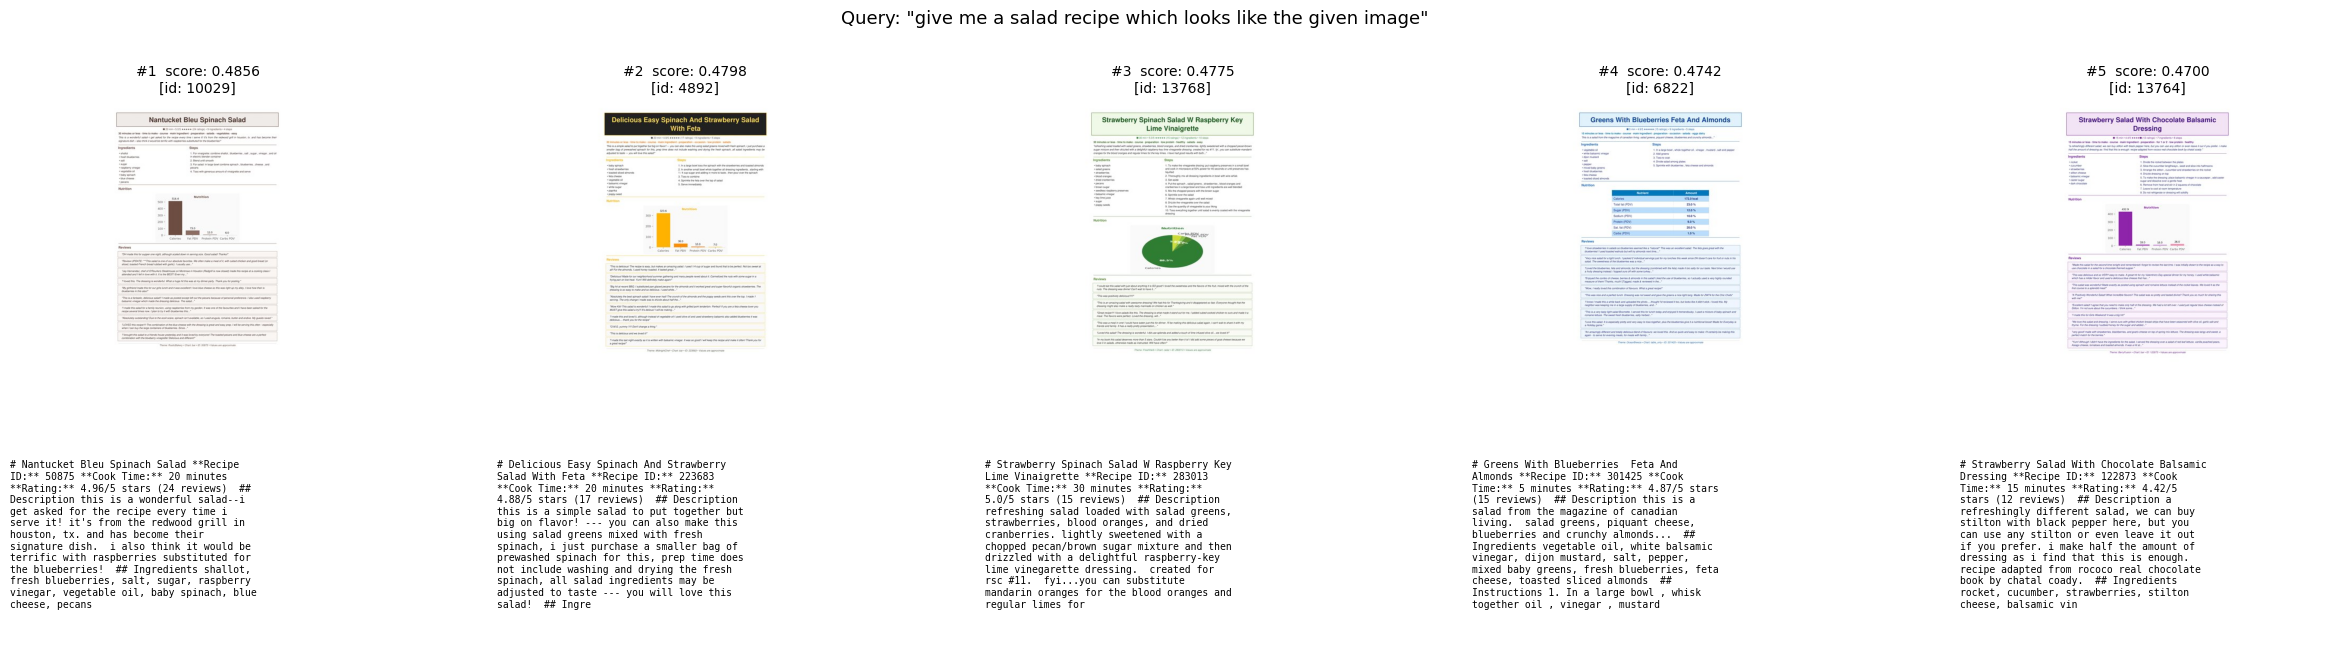

In [8]:
text_query  = "give me a salad recipe which looks like the given image"
image_query = load_image("sample/example_ingredients.jpg")

results = query_qdrant(
    embedding_model=embedding_model,
    qdrant_client=qdrant_client,
    text_query=text_query,
    image_query=image_query,
    top_k=5,
)

display_results(results, query_label=text_query)

## (Optional) Save the figure to disk

In [ ]:
import os
os.makedirs("outputs", exist_ok=True)

display_results(
    results,
    query_label=text_query,
    save_path="outputs/last_query_results.png",
)

## (Optional) Inspect a single result

In [9]:
# Print the full markdown of the top result
print(results[0]['markdown'])

# Nantucket Bleu Spinach Salad
**Recipe ID:** 50875
**Cook Time:** 20 minutes
**Rating:** 4.96/5 stars (24 reviews)

## Description
this is a wonderful salad--i get asked for the recipe every time i serve it! it's from the redwood grill in houston, tx. and has become their signature dish.  i also think it would be terrific with raspberries substituted for the blueberries!

## Ingredients
shallot, fresh blueberries, salt, sugar, raspberry vinegar, vegetable oil, baby spinach, blue cheese, pecans

## Instructions
1. For vinaigrette: combine shallot , blueberries , salt , sugar , vinegar , and oil in electric blender container
2. Blend until smooth
3. For salad: in large bowl combine spinach , blueberries , cheese , and pecans
4. Toss with generous amount of vinaigrette and serve

## Nutrition (PDV)
Calories: 516.4, Total Fat: 73.0, Sugar: 56.0, Sodium: 26.0, Protein: 12.0, Saturated Fat: 40.0

## Reviews
- Outstanding. Made it last night for dinner, to rave reviews. I'm serving at my mom

In [11]:
len(results)

5

In [ ]:
# Display only the top result image
from retrieval.visualizer import display_single
display_single(results[0], query_label=text_query)